In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris

In [2]:
# 데이터 준비 1
iris_dataset = load_iris()
X = iris_dataset['data']
y = iris_dataset['target']

In [67]:
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [66]:
iris_dataset['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [57]:
# 데이터 준비 2 - 훈련세트 / 테스트세트 분할

import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42,    # 매번 같은 구성이 반환되도록 설정
                                                    stratify=y) # 훈련/테스트 데이터의 분포가 y의 분포와 같도록 설정

np.unique(y_train, return_counts=True) # 배열에 포함된 고유한 각 값이 몇 개씩 있는지 확인

(array([0, 1, 2]), array([40, 40, 40], dtype=int64))

In [58]:
# 모델 생성
knn_model = KNeighborsClassifier()

In [59]:
# 모델 훈련
# knn_model.fit(X, y) # 전체 데이터로 훈련
knn_model.fit(X_train, y_train) # 훈련세트로 훈련

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [60]:
import pickle

with open('models/iris_model.pickle', 'wb') as f:
    pickle.dump(knn_model, f) # 모델을 파일에 저장

In [61]:
with open('models/iris_model.pickle', 'rb') as f:
    knn_model_from_file = pickle.load(f) # 파일에 저장된 모델 복원

In [63]:
# 모델 테스트
predicted_y = knn_model_from_file.predict(X_test) # 모든 데이터에 대해 일괄 처리
accuracy = (predicted_y == y_test).sum() / len(y_test)
print(f"Accuracy : {accuracy}")

accuracy2_1 = knn_model_from_file.score(X_train, y_train) # 분류 모델인 경우 accuracy 계산
accuracy2_2 = knn_model_from_file.score(X_test, y_test) # 분류 모델인 경우 accuracy 계산
print(f"Accuracy : {accuracy2_1} / {accuracy2_2}")

Accuracy : 1.0
Accuracy : 0.9666666666666667 / 1.0


In [22]:
test_data = [[2.7, 4.6, 3.5, 5.9]]
pv = knn_model.predict(test_data)
iris_dataset['target_names'][pv]

array(['virginica'], dtype='<U10')

In [23]:
# 실습 : wine_dataset을 사용해서 knn 모델 훈련

In [24]:
# 패키지 준비
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [25]:
# 데이터 준비
wine_dataset = load_wine()

X = wine_dataset['data']
y = wine_dataset['target']

In [26]:
# 훈련 데이터 / 테스트 데이터 분할

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((142, 13), (36, 13))

In [27]:
# 모델 준비
knn_model = KNeighborsClassifier()

In [28]:
# 모델 훈련
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [29]:
# 모델 테스트 (평가) - 과소 적합 상황으로 추정

knn_model.score(X_train ,y_train), knn_model.score(X_test, y_test)

(0.7816901408450704, 0.8055555555555556)

In [30]:
# 모델 성능 개선을 위해 데이터 전처리 추가 - 입력 데이터 스케일 조정

mms = MinMaxScaler()
X_train_scaled = mms.fit_transform(X_train) # 훈련 데이터의 스케일 전처리는 훈련 데이터를 기준으로 학습 + 변환
X_test_scaled = mms.transform(X_test) # 테스트 데이터의 스케일 전처리는 변환만 적용 (학습 X)

In [31]:
# 전처리된 데이터로 모델 훈련

knn_model2 = KNeighborsClassifier()
knn_model2.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [32]:
# 모델 테스트 (평가)

knn_model2.score(X_train_scaled, y_train), knn_model2.score(X_test_scaled, y_test)

(0.971830985915493, 1.0)

In [33]:
# 개발된 모델 사용

# 1. 신규 데이터 준비 (여기서는 테스트 데이터셋에서 가져오기)
test_data = X_test_scaled[:2]

# 2. 와인 등급 예측
predicted_class = knn_model2.predict(test_data)
predicted_class

# 3. 예측 강도 확인
knn_model2.predict_proba(test_data)

array([[1. , 0. , 0. ],
       [0. , 0.4, 0.6]])

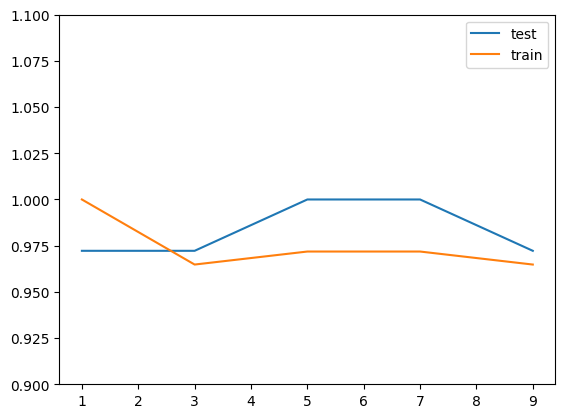

In [34]:
# 이웃의 갯수를 조정해서 모델 성능 최적화

import matplotlib.pyplot as plt

scores = []
scores2 = []
for n in [1, 3, 5, 7, 9]: # 이웃 갯수를 변경하면서 모델 성능 테스트 반복
    m = KNeighborsClassifier(n_neighbors=n)
    m.fit(X_train_scaled, y_train)
    score = m.score(X_test_scaled, y_test) # 테스트 데이터 평가 점수
    scores.append(score)
    scores2.append(m.score(X_train_scaled, y_train)) # 훈련 데이터 평가 점수

plt.plot([1, 3, 5, 7, 9], scores, label='test')
plt.plot([1, 3, 5, 7, 9], scores2, label='train')
plt.ylim(0.9, 1.1)
plt.legend()
plt.show()

In [35]:
# KNN 기반 회귀 모델 훈련

In [36]:
# 패키지 준비

from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [37]:
# 데이터 준비 1
diabetes_dataset = load_diabetes()
# print( diabetes_dataset['DESCR'] ) # 제공된 데이터셋에 대한 설명

X = diabetes_dataset['data']
y = diabetes_dataset['target']

In [38]:
# 데이터 준비 2 - 훈련 데이터 세트 / 테스트 데이터 세트 분할

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=42) # 회귀 목적 데이터인 경우 stratify 사용할 필요 없음

In [39]:
# 데이터 전치리 필요한지 확인 -> 스케일링 불필요
print( X_train.min(axis=0), X_train.max(axis=0) )
print( X_train.max(axis=0) - X_train.min(axis=0) )

[-0.10722563 -0.04464164 -0.08919748 -0.1123988  -0.10889328 -0.11561307
 -0.10230705 -0.0763945  -0.12609712 -0.13776723] [0.11072668 0.05068012 0.16085492 0.13204362 0.15391371 0.19878799
 0.18117906 0.18523444 0.13359728 0.13561183]
[0.21795231 0.09532176 0.2500524  0.24444242 0.262807   0.31440106
 0.28348611 0.26162895 0.2596944  0.27337906]


In [40]:
# y 변수 확인 -> 타겟은 범주형이 아니고 수치형 값 -> 회귀 모델 적용 필요
y[:5]

array([151.,  75., 141., 206., 135.])

In [41]:
# 모델 생성
knn_regressor = KNeighborsRegressor() # 기본 이웃 갯수는 5

In [42]:
# 모델 훈련
knn_regressor.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [43]:
# 모델 테스트 (평가) 1

knn_regressor.score(X_train, y_train), knn_regressor.score(X_test, y_test)

(0.5838666532448267, 0.43016439526042805)

In [44]:
# 모델 테스트 (평가) 2
import numpy as np

predicted_values = knn_regressor.predict(X_test) # 값 예측
np.abs(y_test - predicted_values).mean() # 오차 절대값 평균

42.77078651685394